## Imports

In [1]:
import hashlib
import json
import os
from pathlib import Path
import re
import time
from dotenv import load_dotenv
from google import genai
from google.genai import types
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, f1_score
from tqdm.auto import tqdm

## Configuration and visualization function

In [2]:
def plot_benchmark_leaderboard(
    df: pd.DataFrame,
    primary_col: str,
    secondary_col: str = None,
    title: str = "Benchmark Leaderboard",
    primary_label: str = None,
    secondary_label: str = None,
    baseline: float = None,
    baseline_label: str = "Baseline",
    xlim: tuple = (0, 100),
):
    """Generates a standardized horizontal bar chart leaderboard for evaluating models."""
    df_sorted = df.sort_values(by=primary_col, ascending=True)

    models = df_sorted.index.tolist()
    primary_scores = df_sorted[primary_col].tolist()

    fig, ax = plt.subplots(figsize=(10, max(4, len(models) * 0.8)), dpi=120)
    y_indices = np.arange(len(models))

    if secondary_col and secondary_col in df_sorted.columns:
        secondary_scores = df_sorted[secondary_col].tolist()
        bar_width = 0.35

        rects1 = ax.barh(
            y_indices + bar_width / 2,
            primary_scores,
            bar_width,
            label=primary_label or primary_col,
            color="#1f77b4",
        )
        rects2 = ax.barh(
            y_indices - bar_width / 2,
            secondary_scores,
            bar_width,
            label=secondary_label or secondary_col,
            color="#aec7e8",
        )
    else:
        bar_width = 0.6
        rects1 = ax.barh(
            y_indices,
            primary_scores,
            bar_width,
            label=primary_label or primary_col,
            color="#1f77b4",
        )

    for rect in rects1:
        width = rect.get_width()
        ax.annotate(
            f"{width:.1f}",
            xy=(width, rect.get_y() + rect.get_height() / 2),
            xytext=(4, 0),
            textcoords="offset points",
            ha="left",
            va="center",
            fontsize=9,
        )

    if baseline is not None:
        ax.axvline(
            baseline,
            color="red",
            linestyle="--",
            linewidth=1.2,
            label=baseline_label,
        )

    ax.set_xlabel("Score")
    ax.set_title(title, fontsize=13, pad=12)
    ax.set_yticks(y_indices)
    ax.set_yticklabels(models, fontsize=10)
    ax.set_xlim(*xlim)
    ax.grid(axis="x", linestyle=":", alpha=0.6)

    handles, _ = ax.get_legend_handles_labels()
    if handles:
        ax.legend(loc="lower right")

    plt.tight_layout()
    plt.show()

## Part 1: Multiple Choice Evaluation

,Accuracy (%),Macro F1,Valid Formats,Total,A,B,C,D,Invalid
DictaLM_3.0_Nemotron_12B_Q4,50.41,0.5003,123,123,44,37,28,14,0
DictaLM_2.0_Instruct_Q4,47.15,0.4675,123,123,28,26,53,16,0
Qwen_3_8B,43.09,0.4299,123,123,35,35,26,27,0
DictaLM_3.0_1.7B_Instruct,34.96,0.3283,123,123,12,54,27,30,0
Gemma_3_4B,34.96,0.3386,123,123,27,54,23,19,0
Llama_3_2,26.83,0.1909,123,123,0,31,85,7,0


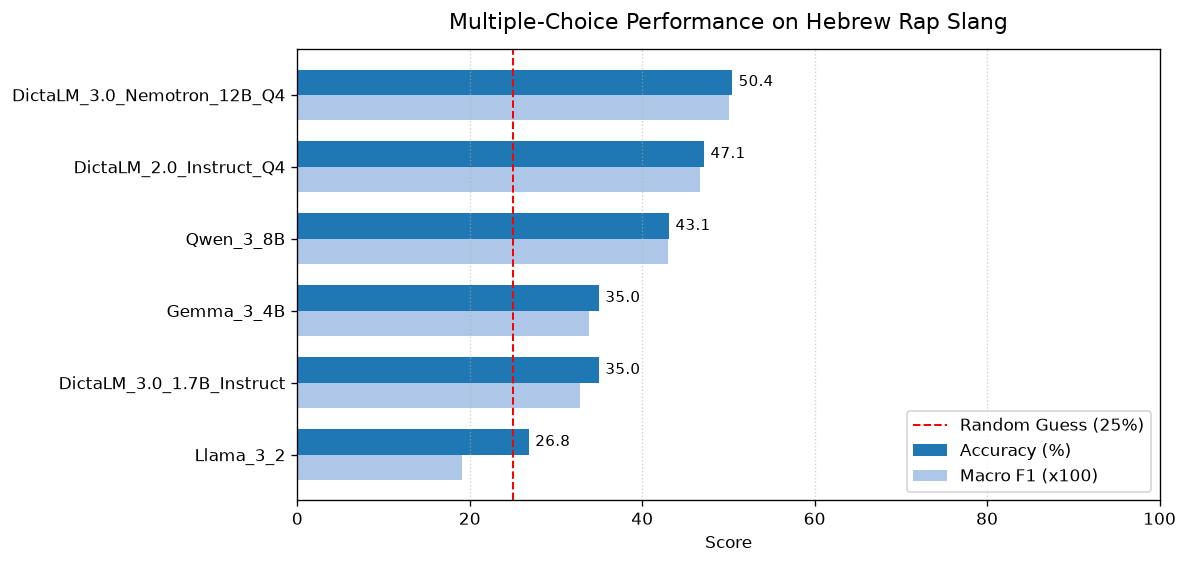

In [3]:
MC_DIR = Path("../data/results/multichoice")

HEBREW_TO_LATIN = {"א": "A", "ב": "B", "ג": "C", "ד": "D"}

def extract_option_letter(val, map_hebrew: bool = True) -> str:
    """Extracts a strict 'A', 'B', 'C', or 'D' option from model output."""
    if not val:
        return "INVALID"

    raw_str = ""
    if isinstance(val, dict):
        raw_str = str(val.get("selected_option", "")).strip()
    else:
        val_str = str(val).strip()
        try:
            parsed = json.loads(val_str)
            if isinstance(parsed, dict) and "selected_option" in parsed:
                raw_str = str(parsed["selected_option"]).strip()
        except Exception:
            pass

        if not raw_str:
            match = re.search(
                r'["\']?selected_option["\']?\s*:\s*["\']?([^"\'}\s,]+)',
                val_str,
                re.IGNORECASE,
            )
            if match:
                raw_str = match.group(1).strip()
            else:
                raw_str = val_str

    candidate = raw_str.upper()

    if map_hebrew and candidate in HEBREW_TO_LATIN:
        candidate = HEBREW_TO_LATIN[candidate]

    if candidate not in {"A", "B", "C", "D"}:
        letter_match = re.search(r"\b([A-D])\b", candidate)
        if letter_match:
            candidate = letter_match.group(1)
        elif map_hebrew:
            heb_match = re.search(r"([א-ד])", raw_str)
            if heb_match:
                candidate = HEBREW_TO_LATIN.get(heb_match.group(1), "INVALID")
        else:
            candidate = "INVALID"

    return candidate if candidate in {"A", "B", "C", "D"} else "INVALID"

mc_results = {}
detailed_predictions = {}

for p in sorted(MC_DIR.glob("*.json")):
    model_name = p.stem
    with p.open("r", encoding="utf-8") as f:
        records = json.load(f)

    y_true = []
    y_pred = []

    for r in records:
        gt = str(r.get("correct_label", "")).strip().upper()
        raw_pred = (
            r.get("predicted_label")
            if r.get("predicted_label") is not None
            else r.get("raw_model_response")
        )
        pred = extract_option_letter(raw_pred, map_hebrew=True)

        y_true.append(gt)
        y_pred.append(pred)

    acc = accuracy_score(y_true, y_pred)
    macro_f1 = f1_score(
        y_true, y_pred, average="macro", labels=["A", "B", "C", "D"], zero_division=0
    )

    pred_series = pd.Series(y_pred)
    pred_counts = pred_series.value_counts().to_dict()
    valid_count = sum(pred_counts.get(k, 0) for k in ["A", "B", "C", "D"])
    invalid_count = len(y_true) - valid_count

    mc_results[model_name] = {
        "Accuracy (%)": round(acc * 100, 2),
        "Macro F1": round(macro_f1, 4),
        "Valid Formats": valid_count,
        "Total": len(y_true),
        "A": pred_counts.get("A", 0),
        "B": pred_counts.get("B", 0),
        "C": pred_counts.get("C", 0),
        "D": pred_counts.get("D", 0),
        "Invalid": invalid_count,
    }
    detailed_predictions[model_name] = pred_series

df_mc = pd.DataFrame.from_dict(mc_results, orient="index").sort_values(
    by="Accuracy (%)", ascending=False
)
display(df_mc)

df_mc["Macro F1 (Scaled)"] = df_mc["Macro F1"] * 100

plot_benchmark_leaderboard(
    df=df_mc,
    primary_col="Accuracy (%)",
    secondary_col="Macro F1 (Scaled)",
    title="Multiple-Choice Performance on Hebrew Rap Slang",
    primary_label="Accuracy (%)",
    secondary_label="Macro F1 (x100)",
    baseline=25.0,
    baseline_label="Random Guess (25%)",
)

## Part 2: Semantic Similarity Scoring

Initializing Gemini API Client for Embeddings...
Computing 123 missing embeddings for ground_truth...


Embedding ground_truth:   0%|          | 0/3 [00:00<?, ?it/s]


Processing DictaLM_2.0_Instruct_Q4...
Computing 123 missing embeddings for DictaLM_2.0_Instruct_Q4...


Embedding DictaLM_2.0_Instruct_Q4:   0%|          | 0/3 [00:00<?, ?it/s]


Processing DictaLM_3.0_1.7B_Instruct...
Computing 123 missing embeddings for DictaLM_3.0_1.7B_Instruct...


...

Embedding Llama_3_2:   0%|          | 0/3 [00:00<?, ?it/s]


Processing Qwen_3_8B...
Computing 123 missing embeddings for Qwen_3_8B...


Embedding Qwen_3_8B:   0%|          | 0/3 [00:00<?, ?it/s]


AVERAGE SEMANTIC SIMILARITY SCORE (0-100)


,Avg Cosine Score
DictaLM_3.0_Nemotron_12B_Q4,73.87
Gemma_3_4B,73.80
DictaLM_2.0_Instruct_Q4,73.45
DictaLM_3.0_1.7B_Instruct,71.27
Qwen_3_8B,71.00
Llama_3_2,64.82


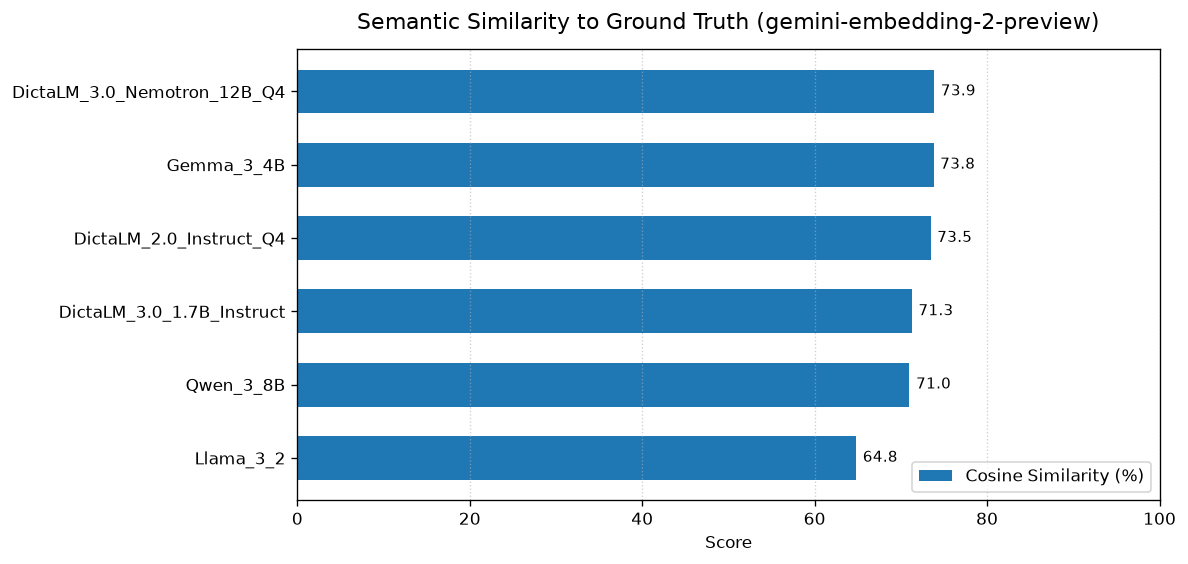

In [4]:
# 1. Paths & Directories
OPEN_DIR = Path("../data/results/open_ended")
EMBEDDINGS_DIR = Path("../data/evaluation/cached_embeddings")
GT_EMBEDDINGS_FILE = EMBEDDINGS_DIR / "ground_truth.npz"

EMBEDDINGS_DIR.mkdir(parents=True, exist_ok=True)

# 2. Client Initialization
print("Initializing Gemini API Client for Embeddings...")
load_dotenv()
client = genai.Client(api_key=os.environ.get("GEMINI_API_KEY"))

# 3. Embedding Caching & Batching Helpers
def load_cached_embeddings(npz_path: Path) -> dict[str, np.ndarray]:
    """Loads cached embeddings dictionary from an .npz file."""
    if not npz_path.exists():
        return {}
    data = np.load(npz_path)
    ids = [str(i) for i in data["ids"]]
    vectors = data["vectors"]
    return dict(zip(ids, vectors))

def save_cached_embeddings(npz_path: Path, cache: dict[str, np.ndarray]):
    """Flushes embedding vectors to disk as a compressed .npz archive."""
    ids = list(cache.keys())
    vectors = np.array(list(cache.values()), dtype=np.float32)
    np.savez_compressed(npz_path, ids=ids, vectors=vectors)

def get_or_compute_embeddings(
    items: list[tuple[str, str]],
    cache_path: Path,
    batch_size: int = 50,
) -> dict[str, np.ndarray]:
    """
    Fetches embeddings from cache or computes missing items via Gemini API.
    Flushes to disk incrementally after each batch to survive interruptions.
    """
    cache = load_cached_embeddings(cache_path)
    missing = [(item_id, text) for item_id, text in items if item_id not in cache]

    if missing:
        print(f"Computing {len(missing)} missing embeddings for {cache_path.stem}...")
        for i in tqdm(range(0, len(missing), batch_size), desc=f"Embedding {cache_path.stem}"):
            batch = missing[i : i + batch_size]
            batch_texts = [text.strip() if text.strip() else " " for _, text in batch]

            # Nested list formatting required for multimodal batching
            formatted_batch = [[t] for t in batch_texts]

            response = client.models.embed_content(
                model="gemini-embedding-2-preview",
                contents=formatted_batch,
            )

            for (item_id, _), emb in zip(batch, response.embeddings):
                cache[item_id] = np.array(emb.values, dtype=np.float32)

            # Persist on-the-run after every single batch
            save_cached_embeddings(cache_path, cache)
            time.sleep(1)
    else:
        print(f"Loaded all {len(items)} embeddings from {cache_path.name}.")

    return cache

def cosine_similarity(vec1: np.ndarray, vec2: np.ndarray) -> float:
    a, b = np.array(vec1), np.array(vec2)
    norm_a, norm_b = np.linalg.norm(a), np.linalg.norm(b)
    if norm_a == 0 or norm_b == 0:
        return 0.0
    return float(np.dot(a, b) / (norm_a * norm_b))

# 4. Load Open-Ended Results
open_results = {}
for p in sorted(OPEN_DIR.glob("*.json")):
    with p.open("r", encoding="utf-8") as f:
        open_results[p.stem] = json.load(f)

# 5. Compute or Load Ground Truth Embeddings
first_model_records = next(iter(open_results.values()))
gt_tuples = [(r["id"], r.get("ground_truth", "")) for r in first_model_records]
gt_embeddings_map = get_or_compute_embeddings(gt_tuples, GT_EMBEDDINGS_FILE)

# 6. Compute Similarities, Update JSONs In-Place
similarity_scores = {}

for model_name, records in open_results.items():
    print(f"\nProcessing {model_name}...")
    model_tuples = [
        (r["id"], r.get("raw_model_response", "")[:4000]) for r in records
    ]
    model_cache_path = EMBEDDINGS_DIR / f"{model_name}.npz"
    model_embeddings_map = get_or_compute_embeddings(model_tuples, model_cache_path)

    scores = []
    for r in records:
        item_id = r["id"]
        gt_vec = gt_embeddings_map[item_id]
        resp_vec = model_embeddings_map[item_id]

        sim = cosine_similarity(gt_vec, resp_vec)
        scaled_sim = round(max(0.0, sim * 100.0), 2)
        scores.append(scaled_sim)

        # Annotate record in-place
        r["cosine_similarity"] = scaled_sim

    # Save enriched record list back to disk
    result_path = OPEN_DIR / f"{model_name}.json"
    with open(result_path, "w", encoding="utf-8") as f:
        json.dump(records, f, ensure_ascii=False, indent=2)

    similarity_scores[model_name] = {
        "Avg Cosine Score": round(float(np.mean(scores)), 2)
    }

# 7. Display Leaderboard & Render Visualization
df_sim = pd.DataFrame.from_dict(similarity_scores, orient="index")
df_sim = df_sim.sort_values(by="Avg Cosine Score", ascending=False)

print("\n" + "=" * 50)
print("AVERAGE SEMANTIC SIMILARITY SCORE (0-100)")
print("=" * 50)
display(df_sim)

plot_benchmark_leaderboard(
    df=df_sim,
    primary_col="Avg Cosine Score",
    title="Semantic Similarity to Ground Truth (gemini-embedding-2-preview)",
    primary_label="Cosine Similarity (%)",
)

## Part 3: LLM-as-a-Judge Scoring

In [5]:
# # 1. Paths & Initialization
# OPEN_DIR = Path("../data/results/open_ended")
# SCORES_DIR = Path("../data/scores")
# JUDGE_CACHE_FILE = Path("../data/llm_judge_cache.json")
#
# SCORES_DIR.mkdir(parents=True, exist_ok=True)
#
# print("Initializing Gemini API Client for LLM-as-a-Judge...")
# load_dotenv()
# client = genai.Client(api_key=os.environ.get("GEMINI_API_KEY"))
#
# # 2. Load Cache (JSON format for readability and safety)
# if JUDGE_CACHE_FILE.exists():
#     with open(JUDGE_CACHE_FILE, "r", encoding="utf-8") as f:
#         judge_cache = json.load(f)
#     print(f"Loaded {len(judge_cache)} cached LLM judge evaluations.")
# else:
#     judge_cache = {}
#     print("No LLM judge cache found. Starting fresh.")
#
# def save_cache():
#     """Flushes in-memory cache to disk immediately."""
#     with open(JUDGE_CACHE_FILE, "w", encoding="utf-8") as f:
#         json.dump(judge_cache, f, ensure_ascii=False, indent=2)
#
# def get_cache_key(item_id: str, model_response: str) -> str:
#     """Creates a unique deterministic key for each specific response."""
#     response_hash = hashlib.md5(str(model_response).encode("utf-8")).hexdigest()
#     return f"{item_id}_{response_hash}"
#
# # 3. Judge Prompt Template
# JUDGE_PROMPT_TEMPLATE = """
# You are an expert linguistic judge evaluating an AI model's understanding of Israeli hip-hop slang.
#
# You will be given a slang fragment, the ground truth explanation (what it actually means), and the AI model's predicted explanation.
# Your task is to grade the AI model's explanation strictly on factual accuracy and semantic equivalence to the ground truth.
#
# Fragment:
# {fragment}
#
# Ground Truth Explanation:
# {ground_truth}
#
# AI Model Explanation:
# {model_response}
#
# Rubric:
# 100: The model's explanation perfectly captures the meaning of the slang in this context.
# 75: The explanation is mostly correct but misses a minor nuance.
# 50: The explanation is partially correct but gets significant parts wrong or is too vague.
# 25: The explanation is mostly incorrect but has a tiny grain of truth.
# 0: The explanation is completely wrong, hallucinates, or is irrelevant.
#
# Output your evaluation strictly as a JSON object with two keys:
# - "score": an integer representing the grade (0, 25, 50, 75, or 100).
# - "reasoning": a one-sentence justification for the score.
# """
#
# def evaluate_response(item_id, fragment, ground_truth, model_response):
#     cache_key = get_cache_key(item_id, model_response)
#
#     # Return immediately if already computed
#     if cache_key in judge_cache:
#         return judge_cache[cache_key], False
#
#     prompt = JUDGE_PROMPT_TEMPLATE.format(
#         fragment=fragment,
#         ground_truth=ground_truth,
#         model_response=str(model_response)[:4000]
#     )
#
#     try:
#         response = client.models.generate_content(
#             model="gemini-3.8-flash",
#             contents=prompt,
#             config=types.GenerateContentConfig(
#                 response_mime_type="application/json",
#                 temperature=0.0,
#                 automatic_function_calling=types.AutomaticFunctionCallingConfig(disable=True),
#             ),
#         )
#
#         result = json.loads(response.text)
#         score = int(result.get("score", 0))
#         reasoning = str(result.get("reasoning", "Failed to parse reasoning."))
#
#         evaluation = {"score": score, "reasoning": reasoning}
#
#         # 1. Update memory cache
#         judge_cache[cache_key] = evaluation
#         # 2. Persist to disk immediately on every successful evaluation
#         save_cache()
#
#         return evaluation, True
#
#     except Exception as e:
#         print(f"\n[!] Error or Quota Exhaustion on item {item_id}: {e}")
#         # Stop execution immediately instead of caching false 0s into the benchmark
#         raise e
#
# # 4. Load all open-ended results
# open_results = {}
# for p in sorted(OPEN_DIR.glob("*.json")):
#     with p.open("r", encoding="utf-8") as f:
#         open_results[p.stem] = json.load(f)
#
# llm_judge_scores = {}
# detailed_judge_scores = {}
#
# print("\nRunning LLM-as-a-Judge Evaluation...")
#
# # 5. Evaluate and update in place with immediate disk persistence
# for model_name, records in open_results.items():
#     print(f"\nEvaluating {model_name}...")
#     result_path = OPEN_DIR / f"{model_name}.json"
#
#     scores = []
#     item_score_map = {}
#
#     for r in tqdm(records, desc=f"{model_name}"):
#         item_id = r.get("id")
#         fragment = r.get("fragment", "")
#         ground_truth = r.get("ground_truth", "")
#         model_resp = r.get("raw_model_response", "")
#
#         evaluation, was_api_call = evaluate_response(item_id, fragment, ground_truth, model_resp)
#
#         score = evaluation["score"]
#         scores.append(score)
#
#         # Attach score and reasoning in-place to the in-memory record
#         r["llm_judge_score"] = score
#         r["llm_judge_reasoning"] = evaluation["reasoning"]
#         item_score_map[item_id] = score
#
#         if was_api_call:
#             # Persist updated model records to disk per item
#             with open(result_path, "w", encoding="utf-8") as f:
#                 json.dump(records, f, ensure_ascii=False, indent=2)
#             time.sleep(2)
#
#     # Ensure final state is written
#     with open(result_path, "w", encoding="utf-8") as f:
#         json.dump(records, f, ensure_ascii=False, indent=2)
#
#     llm_judge_scores[model_name] = {
#         "Avg Judge Score": round(float(np.mean(scores)), 2)
#     }
#     detailed_judge_scores[model_name] = item_score_map
#
# # 6. Export Consolidated Summary
# with open(SCORES_DIR / "llm_judge_summary.json", "w", encoding="utf-8") as f:
#     json.dump({
#         "aggregated": llm_judge_scores,
#         "per_item": detailed_judge_scores
#     }, f, ensure_ascii=False, indent=2)
# print(f"\nSaved consolidated summary to {SCORES_DIR / 'llm_judge_summary.json'}")
#
# # 7. Display Leaderboard & Render Visualization
# df_judge = pd.DataFrame.from_dict(llm_judge_scores, orient="index")
# df_judge = df_judge.sort_values(by="Avg Judge Score", ascending=False)
#
# print("\n" + "=" * 50)
# print("LLM-AS-A-JUDGE SCORES (0-100)")
# print("=" * 50)
# display(df_judge)
#
# plot_benchmark_leaderboard(
#     df=df_judge,
#     primary_col="Avg Judge Score",
#     title="LLM-as-a-Judge Accuracy (gemini-3.8-flash)",
#     primary_label="Factual Accuracy Score"
# )

## Part 4: Aggregated Leaderboard & Visualization